## Polytope On-Demand DT Feature Extraction

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.


Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run ../desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [ ]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-plots
* pip install cf-units         (Optional for unit conversion in maps)

In [ ]:
import earthkit.data
import earthkit.regrid
from earthkit.plots.interactive import Chart

In [ ]:
# Defaults to making a live data request. Set to false to use the cached GRIB file instead.
import os

LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"
LIVE_REQUEST

In [ ]:
request = {
    "class": "d1",
    "dataset": "on-demand-extremes-dt",
    "stream": "oper",
    "type": "fc",
    "date": "20250926",
    "time": "0000",
    "levtype": "pl",
    "expver": "0099",
    "param": "133",
    "step": "5",
    "georef": "gcgkrb",
    "levelist": "1/to/1000",
    "feature": {
        "type": "verticalprofile",
        "points": [[38.9, -9.1]],
    },
}

In [ ]:
data_file = "../data/on-demand-extremes-dt-vertical-profile-fe-example.covjson"
if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

In [ ]:
# Convert data to xarray
da = data.to_xarray()
da

<xarray.Dataset> Size: 400B
Dimensions:    (latitude: 1, longitude: 1, number: 1, datetime: 1, time: 1,
                levelist: 18)
Coordinates:
  * latitude   (latitude) float64 8B 58.14
  * longitude  (longitude) float64 8B 0.0007623
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2025-09-26T00:00:00Z'
  * time       (time) int64 8B 5
  * levelist   (levelist) int64 144B 50 100 150 200 250 ... 900 925 950 975 1000
Data variables:
    q          (latitude, longitude, number, datetime, time, levelist) float64 144B ...
Attributes:
    class:          d1
    dataset:        on-demand-extremes-dt
    stream:         oper
    expver:         0099
    type:           fc
    Forecast date:  2025-09-26T00:00:00Z
    levtype:        pl
    georef:         gcgkrb
    levelist:       50
    number:         0

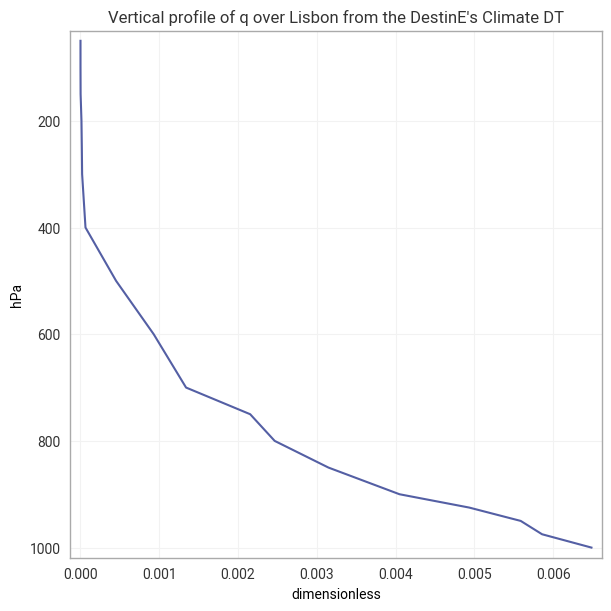

In [ ]:
chart = earthkit.plots.Subplot(size=(6, 6))

chart.line(da, x="q")

chart.title("Vertical profile of {variable_name} over Lisbon from the DestinE's Climate DT")

chart.ylabel("hPa")
chart.xlabel("{units}")

chart.ax.invert_yaxis()

chart.show()